### Pipeline to train model with decision tree classifier without removal of outlier
- Testing:
```
Accuracy: 0.9018796639069521
              precision    recall  f1-score   support

           0       0.98      0.90      0.93    967950
           1       0.71      0.93      0.80    265994
```
- Validation
```
Accuracy: 0.7768505161854179
              precision    recall  f1-score   support

           0       0.79      0.99      0.87   1634501
           1       0.14      0.01      0.02    444500
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load the datasets

In [2]:
df_1 = df = pd.read_csv("../Dataset/S2_chest_data.csv")
print("loaded df_1")
df_2 = df = pd.read_csv("../Dataset/S3_chest_data.csv")
print("loaded df_2")
df_3 = df = pd.read_csv("../Dataset/S9_chest_data.csv")
print("loaded df_3")

loaded df_1
loaded df_2
loaded df_3


### Combine the datasets

In [3]:
df = pd.concat([df_1, df_2, df_3], ignore_index=True)
df.shape

(12456500, 9)

### Drop duplicate

In [4]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label
count,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06
mean,8.163643e-01,-2.747610e-02,-2.947599e-01,1.532798e-03,-2.864552e-03,2.768166e+00,3.460153e+01,6.384749e-02,1.502968e+00
std,1.226097e-01,8.166216e-02,3.004658e-01,2.279383e-01,1.556006e-02,6.799757e-01,3.334515e-01,4.397762e+00,1.675910e+00
min,3.278000e-01,-3.730000e-01,-1.835000e+00,-1.499680e+00,-4.740601e-01,1.320267e+00,3.359134e+01,-4.582672e+01,0.000000e+00
25%,7.886000e-01,-6.300002e-02,-4.990000e-01,-7.374573e-02,-1.066589e-02,2.200317e+00,3.437039e+01,-2.369690e+00,0.000000e+00
50%,8.570000e-01,-3.179997e-02,-2.674000e-01,-2.838135e-02,-2.243042e-03,2.840424e+00,3.470621e+01,-2.731323e-01,1.000000e+00
75%,8.994000e-01,4.999995e-03,-7.859999e-02,8.857727e-02,5.355835e-03,3.204727e+00,3.487085e+01,2.455139e+00,3.000000e+00
max,1.966800e+00,3.346000e-01,1.086600e+00,1.499954e+00,3.534393e-01,4.241943e+00,3.523074e+01,3.297272e+01,7.000000e+00


### Data filtering

In [5]:
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]

### Categorization

In [6]:
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

df["Label"] = df["Label"].apply(apply_target)

### handle -ve EMG

In [7]:
df["EMG"] = df["EMG"].abs()

### Handling the -Ve temp value

In [8]:
df = df[df["Temp"] > 0]

### Train test split

In [9]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

### Balance out the train dataset only

In [10]:
from sklearn.utils import resample

# majority class
low_stress = train[train["Label"] == 0]

# minority class
high_stress = train[train["Label"] == 1]

low_downsampled = resample(
    low_stress,
    replace=False,
    n_samples=len(high_stress),
    random_state=42
)

train = pd.concat([low_downsampled, high_stress]).sample(frac=1)

train['Label'].value_counts()

Label
1    1063923
0    1063923
Name: count, dtype: int64

### Train the model

In [11]:
x_train = train.drop("Label", axis=1)
y_train = train["Label"]

In [11]:
pd.DataFrame(x_train).describe()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp
count,722598.000000,722598.000000,722598.000000,722598.000000,722598.000000,722598.000000,722598.000000,722598.000000
mean,0.795937,-0.012026,-0.424308,0.001305,0.010032,2.854711,34.539902,0.064735
std,0.116160,0.060445,0.199822,0.216394,0.009376,0.713578,0.279139,3.702452
min,0.331000,-0.344600,-1.050200,-1.090622,0.000000,1.421738,33.718567,-17.558289
25%,0.789000,-0.038200,-0.502600,-0.068344,0.003342,2.137756,34.401000,-2.290344
50%,0.821600,-0.029000,-0.440200,-0.024857,0.007507,3.051758,34.580260,-0.291443
75%,0.870000,-0.005400,-0.297800,0.084045,0.013870,3.379822,34.723114,2.209473
max,1.209200,0.334600,0.523400,1.499405,0.171890,4.049683,35.102325,19.541931


In [12]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

model = DecisionTreeClassifier(
    criterion='gini',       # 'gini' or 'entropy'
    max_depth=4,            # prevents overfitting
    min_samples_split=5,    # min samples to split a node
    min_samples_leaf=2,     # min samples in a leaf
    random_state=42
)

y_train = train["Label"]

model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [13]:
feature_importance = pd.DataFrame({
    'Feature': df.drop("Label", axis=1).columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

Feature  Importance
  ACC_X    0.365280
    EDA    0.329755
  ACC_Z    0.252943
  ACC_Y    0.050166
   Temp    0.001055
   Resp    0.000801
    ECG    0.000000
    EMG    0.000000


### Test the model with test dataset

In [14]:
X_test = test.drop("Label", axis=1)

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, classification_report
y_test = test["Label"]
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9018796639069521
              precision    recall  f1-score   support

           0       0.98      0.90      0.93    967950
           1       0.71      0.93      0.80    265994

    accuracy                           0.90   1233944
   macro avg       0.84      0.91      0.87   1233944
weighted avg       0.92      0.90      0.91   1233944



### Test model on other Dataset

In [17]:
validate_df =  pd.read_csv("../Dataset/S4_chest_data.csv")

In [18]:
# filtering the dataset
accept_label = [1, 2, 3, 4]
validate_df = validate_df[validate_df["Label"].isin(accept_label)]

# categorization
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

validate_df["Label"] = validate_df["Label"].apply(apply_target)

# handling -ve EMG value
validate_df["EMG"] = validate_df["EMG"].abs()


In [19]:
X_Validate = validate_df.drop("Label", axis=1)   
y_validate = validate_df["Label"]

In [20]:
y_pred = model.predict(X_Validate)


print("Accuracy:", accuracy_score(y_validate, y_pred))
print(classification_report(y_validate, y_pred))

Accuracy: 0.7768505161854179
              precision    recall  f1-score   support

           0       0.79      0.99      0.87   1634501
           1       0.14      0.01      0.02    444500

    accuracy                           0.78   2079001
   macro avg       0.46      0.50      0.45   2079001
weighted avg       0.65      0.78      0.69   2079001



### LIME

In [35]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=x_train.values,
    feature_names=train.drop("Label", axis=1).columns,
    mode="classification",
    discretize_continuous=False
)

In [44]:
input_data = pd.DataFrame([{
    "ACC_X": 1.2,
    "ACC_Y": -0.5,
    "ACC_Z":0.5,
    "ECG": 0.5,
    "EMG": 0.01,
    "EDA": 0.005,
    "Temp": 30.30,
    "Resp": -0.40
}])



explanation = explainer.explain_instance(
    data_row=input_data.iloc[0].values,   # <-- FIX
    predict_fn=model.predict_proba,
    num_features=8
)

explanation.as_list()

c:\Users\Yadnesh\OneDrive\Desktop\codes\XAI_For_Stress_and_Mental_Health_Prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


[('ACC_Z', -0.139717364049908),
 ('EDA', -0.10564396268399),
 ('ACC_X', 0.036689957370366386),
 ('ACC_Y', 0.023875648435730243),
 ('Temp', 0.0221497700996045),
 ('EMG', -0.009189473389859634),
 ('ECG', -0.0036477628284567708),
 ('Resp', 0.0016019265419406354)]

In [45]:
model.classes_

array([0, 1])

In [46]:
model.predict_proba(input_data)

array([[9.99783519e-01, 2.16481455e-04]])

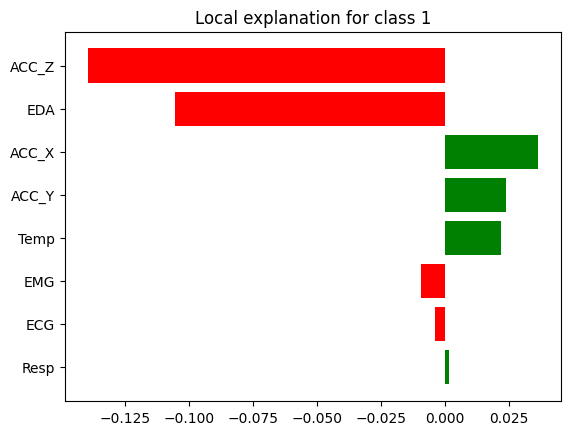

In [47]:
import matplotlib.pyplot as plt

fig = explanation.as_pyplot_figure()
plt.show()

### SHAP

In [27]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

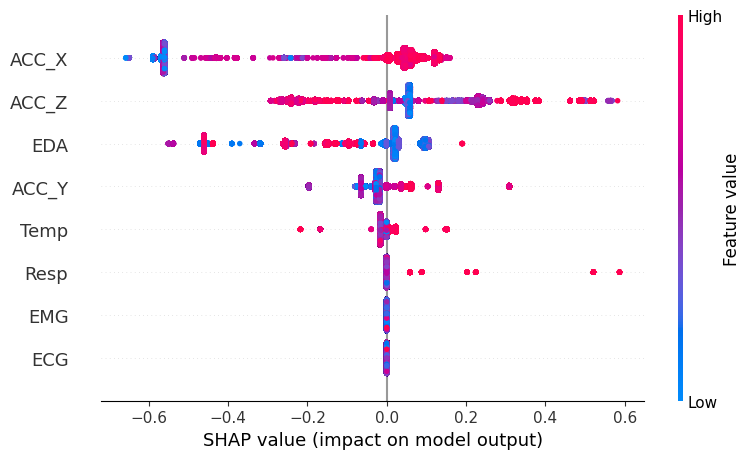

In [28]:
shap.summary_plot(shap_values[:,:,1], X_test)